In [27]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [28]:
custom_map = [
    "FFSF",
    "FHFH",
    "FFFH",
    "HGFF"
]

In [29]:
env = gym.make("FrozenLake-v1", is_slippery=True)

In [30]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [31]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((env.observation_space.n, env.action_space.n))

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """
    if np.random.uniform(0, 1) < epsilon:
        return env.action_space.sample()  # Explore: choose a random action
    else:
        return np.argmax(Q[state, :])    # Exploit: choose the action with max Q-value


In [32]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset() # Initial state
    action = epsilon_greedy_action(state, epsilon) # Initial action

    done = False
    truncated = False
    rewards_current_episode = 0

    for step in range(max_steps_per_episode):
        next_state, reward, done, truncated, _ = env.step(action)
        next_action = epsilon_greedy_action(next_state, epsilon) # Select next action using epsilon-greedy

        # SARSA Update Rule
        Q[state, action] = Q[state, action] + alpha * \
                           (reward + gamma * Q[next_state, next_action] - Q[state, action])

        state = next_state
        action = next_action
        rewards_current_episode += reward

        if done or truncated:
            break

    # Epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(rewards_current_episode)


# Derive state-value function and policy from the learned Q-table
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)


In [33]:
env = gym.make("FrozenLake-v1", is_slippery=True, desc=custom_map)

In [34]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    value_grid = np.round(values.reshape(4, 4), 3).astype(str)
    # Mark the start (state 0) and goal (state 15)
    value_grid[0, 2] = 'S'
    value_grid[3, 1] = 'G'
    print(value_grid)


def print_policy(policy):
    action_symbols = {
        0: "←", # Left
        1: "↓", # Down
        2: "→", # Right
        3: "↑"  # Up
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    # Mark the start (state 0) and goal (state 15)
    policy_grid[0, 2] = 'S'
    policy_grid[3, 1] = 'G'

    print("\nLearned Policy:")
    print(policy_grid)


In [35]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.393 0.38  0.379 0.363]
 [0.25  0.26  0.221 0.324]
 [0.29  0.288 0.278 0.284]
 [0.201 0.242 0.241 0.281]
 [0.414 0.283 0.307 0.305]
 [0.    0.    0.    0.   ]
 [0.257 0.149 0.132 0.113]
 [0.    0.    0.    0.   ]
 [0.223 0.359 0.342 0.476]
 [0.379 0.515 0.457 0.371]
 [0.48  0.341 0.275 0.274]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.387 0.426 0.621 0.579]
 [0.669 0.813 0.7   0.637]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[['0.393' '0.324' 'S' '0.281']
 ['0.414' '0.0' '0.257' '0.0']
 ['0.476' '0.515' '0.48' '0.0']
 ['0.0' 'G' '0.813' '0.0']]

Learned Policy:
[['←' '↑' 'S' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' 'G' '↓' '←']]

Average reward over last 1000 episodes: 0.53


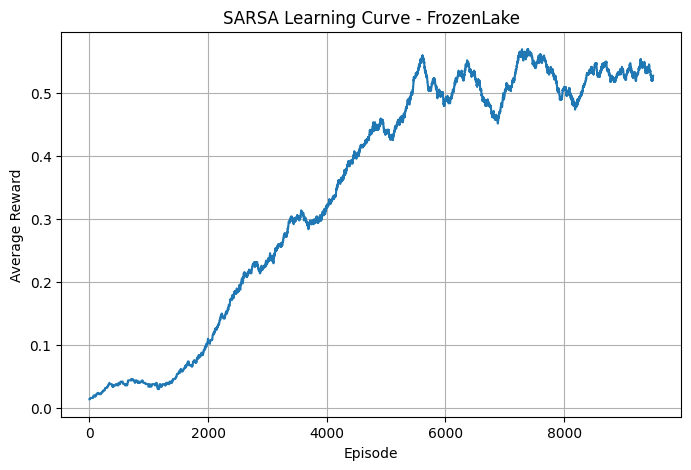

In [36]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()